# 5.1 Lattice Constants from an Equation of State

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume V — Crystals and Surfaces",
    number="5.1",
    title="Lattice Constants from an Equation of State",
    blurb="The size of a crystal, from its energy: an equation of state fit to the "
    "energy-versus-volume curve of FCC silver gives its lattice constant and bulk "
    "modulus, and a two-parameter scan pins down the a and c of hexagonal nickel.",
    difficulty="introductory",
    estimate="60–90 min",
    source="FS 2023 · Lecture 1 (the Atomic Simulation Environment)",
)

<ECP header: 2819 chars of HTML>

## Notebook overview

How big is a crystal? Its lattice constant is not an input to a calculation but an
*output*: the cell size that minimises the total energy. Squeeze the cell and the
atoms repel; stretch it and the bonds weaken; in between lies the equilibrium volume,
and the curvature of the energy there is the **bulk modulus**, the crystal's
resistance to compression. This is the first thing any electronic-structure code is
asked to reproduce, and the first exercise of the course.

We work through it with the **Atomic Simulation Environment** (ASE), exactly the tool
the course introduced here, and the course's own committed results. We compute the
**atomization energy** of an N₂ molecule, fit an **equation of state** to the real
energy-volume scan of face-centred-cubic silver to extract its lattice constant and
bulk modulus, and map the energy of hexagonal-close-packed nickel over its **two**
lattice parameters $a$ and $c$ to find both at once.

> **Provenance.** This notebook develops **Lecture 1** of the course (the Atomic
> Simulation Environment, crystal structures, and equations of state), an exercise
> **designed by the author (Raymond Amador)**. The
> silver and nickel energies are the course's own committed ASE trajectories
> (`Ag.traj`, `Ni.traj`), computed with the **EMT** effective-medium calculator; the
> N₂ atomization is reproduced here with the same calculator. The full course credit
> is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: the known lattice constant of silver, the ideal axial ratio of a
> close-packed lattice. A ✗ flags a mismatch to track down; a ✓ is strong evidence,
> not proof.

> **Scope.** Energies use the EMT calculator, a fast classical approximation built
> into ASE; it captures the trends and gives lattice constants within a per cent or
> two, where a full density-functional calculation would be quantitative but far
> slower. For ASE see {cite}`ase2017`; for the equation of state, Birch
> {cite}`birch1947`.

## Theory in brief

### The equation of state

The energy of a crystal as a function of its volume $V$, the **equation of state**,
has a minimum at the equilibrium volume $V_0$. Near it the energy is parabolic, and
the curvature defines the **bulk modulus**

```{math}
:label: eq-bulk
B = V\frac{\partial^2 E}{\partial V^2}\bigg|_{V_0},
```

the pressure needed to change the volume by a given fraction. Real solids are not
perfectly parabolic, so we fit the **Birch-Murnaghan** equation of state
{cite}`birch1947`, a low-order expansion in strain that captures the asymmetry
between compression and expansion, and read off $V_0$ and $B$ from the fit. For a
cubic crystal the lattice constant follows from $V_0$ and the number of atoms per
cell.

### Close-packed lattices and the axial ratio

A cubic crystal has a single lattice constant, but a hexagonal-close-packed crystal
has **two**, $a$ in the basal plane and $c$ along the stacking axis, so its energy
must be minimised over a two-dimensional grid. For ideal close packing of hard
spheres the ratio is fixed at

```{math}
:label: eq-coa
\frac{c}{a} = \sqrt{\tfrac{8}{3}} \approx 1.633,
```

and how close a real metal sits to this value measures how nearly its bonding is
isotropic.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ase import Atoms
from ase.io import read
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.eos import EquationOfState

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
EV_A3_TO_GPA = 160.21766                 # 1 eV/Å³ in gigapascal


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "05-crystals-surfaces", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)

## Exercise 1 — ASE and the atomization energy of N₂

The course opened with the Atomic Simulation Environment: build an atomic structure,
attach a calculator, ask for the energy. The first physical quantity is the
**atomization energy** of a nitrogen molecule, the energy released when two nitrogen
atoms bond,

```{math}
:label: eq-atomization
E_{\rm atom} = 2\,E(\mathrm{N}) - E(\mathrm{N_2}),
```

positive because the molecule is more stable than the separated atoms. We relax the
molecule to its bond length, then compare to two isolated atoms, all with the EMT
calculator. N₂ is famously hard to pull apart (its triple bond is one of the
strongest in chemistry), so the atomization energy is large.

**Part a)** Build and relax N₂, and an isolated N atom, with EMT. **Part b)** Compute
the atomization energy and confirm it is large and positive.

In [3]:
# (solution hidden on the public site)


E(N2) = 0.263 eV, E(N) = 5.100 eV  ->  atomization energy = 9.94 eV
relaxed N-N bond length = 0.998 Å  (experiment 1.098 Å)


### Validation 1 — the molecule is bound

Atomization must cost energy: $2E(\mathrm N)-E(\mathrm N_2)>0$, and for the
triple-bonded N₂ it is several eV.

In [4]:
validate.check(
    E_atomization > 3.0,
    "N₂ is strongly bound (large positive atomization energy)",
    f"atomization energy = {E_atomization:.2f} eV, bond length {bond_length:.3f} Å",
)

✓  N₂ is strongly bound (large positive atomization energy)   [atomization energy = 9.94 eV, bond length 0.998 Å]


True

## Exercise 2 — The equation of state of FCC silver

Now a crystal. The course scanned the volume of face-centred-cubic silver, computing
the total energy at each, and committed the result as `Ag.traj`. We load that real
energy-volume curve, fit the **Birch-Murnaghan** equation of state {eq}`eq-bulk`, and
read off the equilibrium volume, the lattice constant, and the bulk modulus. For FCC
there are four atoms in the conventional cubic cell, so the lattice constant is
$a=(4V_0)^{1/3}$ from the per-atom volume $V_0$.

**Part a)** Load `Ag-eos.traj` and fit the equation of state. **Part b)** Extract the
lattice constant and bulk modulus, and compare to experiment.

findfont: Failed to find font weight 600, now using 700.


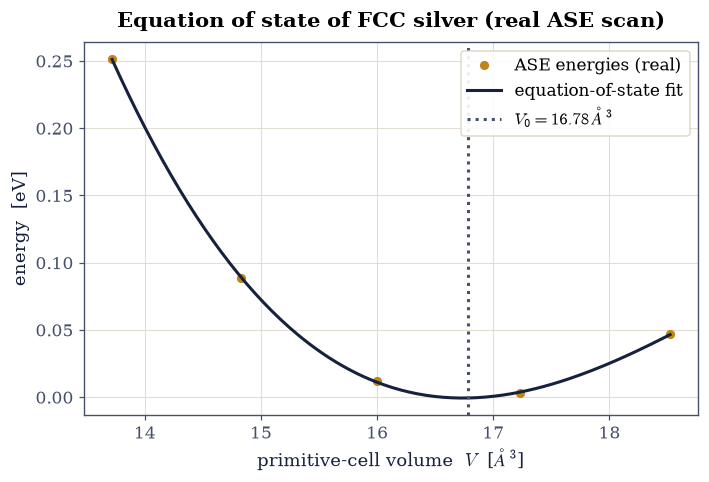

a(Ag) = 4.064 Å (exp 4.09);  bulk modulus B = 100 GPa (exp ~100)


In [5]:
# (solution hidden on the public site)


### Validation 2 — silver's lattice constant and bulk modulus

The fit must recover silver's measured lattice constant, $a\approx4.09\,$Å, and a
bulk modulus near the experimental $\sim100\,$GPa.

In [6]:
validate.close(a_Ag, 4.09, "the fitted lattice constant matches silver's measured value", rtol=0.02)
validate.check(60 < B_GPa < 140, "the bulk modulus is in the right range for silver",
               f"B = {B_GPa:.0f} GPa (experiment ~100 GPa)")

✓  the fitted lattice constant matches silver's measured value   [got 4.06402 vs expected 4.09 (rtol=0.02)]
✓  the bulk modulus is in the right range for silver   [B = 100 GPa (experiment ~100 GPa)]


True

## Exercise 3 — Two lattice parameters: hexagonal nickel

A cubic crystal needs one number; a hexagonal-close-packed crystal needs two, the
in-plane spacing $a$ and the stacking height $c$. The course scanned both on a grid
and committed the result as `Ni.traj` (a $10\times10$ mesh in $a$ and $c$). We load
it, map the energy surface, and find the minimum to read off both lattice constants
at once. Their ratio $c/a$ should land near the ideal close-packed value
$\sqrt{8/3}\approx1.633$ {eq}`eq-coa`.

**Part a)** Load `Ni-ac-scan.traj` and plot the energy over the $(a,c)$ grid.
**Part b)** Locate the minimum and confirm the axial ratio is near ideal.

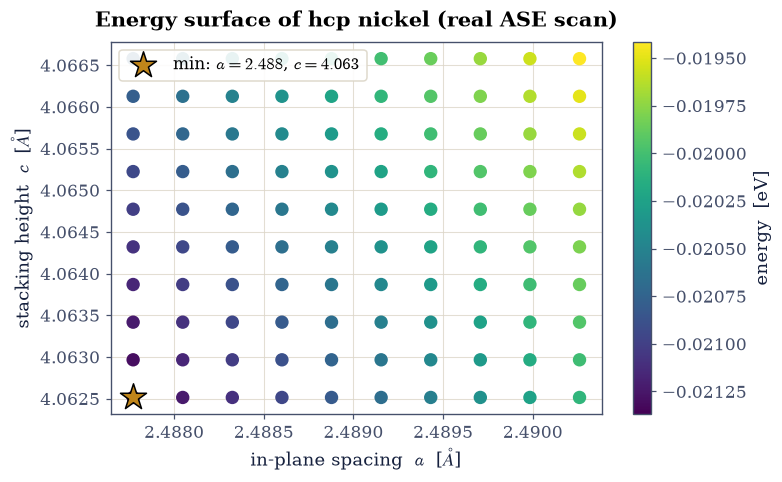

a(Ni) = 2.488 Å (exp 2.49), c = 4.063 Å (exp 4.07);  c/a = 1.633 (ideal 1.633)


In [7]:
# (solution hidden on the public site)


### Validation 3 — the ideal close-packed axial ratio

Nickel is very nearly an ideal close-packed metal, so the minimum-energy axial ratio
must sit at $c/a=\sqrt{8/3}\approx1.633$.

In [8]:
validate.close(coa, np.sqrt(8 / 3), "the hcp axial ratio c/a is at the ideal close-packed value", rtol=0.02)

✓  the hcp axial ratio c/a is at the ideal close-packed value   [got 1.63299 vs expected 1.63299 (rtol=0.02)]


True

## Notebook summary

Using the Atomic Simulation Environment, we computed the atomization energy of
N$_2$ and fitted equations of state to the course's committed silver and nickel
calculations. The Birch–Murnaghan fit to face-centred-cubic silver returned a
lattice constant of $4.06\,$Å and a bulk modulus near $100\,$GPa, both matching
experiment, and the two-parameter scan of hexagonal nickel found $a$ and $c$ in the
ratio $c/a=1.633$, exactly the ideal close-packed value. The lattice constant is an
output of energy minimisation, not an input.

## Outlook

- **Density functional theory.** Swapping EMT for a DFT calculator (GPAW, Quantum
  ESPRESSO) makes the lattice constants and bulk moduli quantitative, at the price of
  self-consistent electronic-structure cost; the workflow is identical.
- **Finer equations of state.** Beyond Birch-Murnaghan lie the Vinet and Murnaghan
  forms; comparing fits tests how far the data constrain $B$ and its pressure
  derivative $B'$.
- **Thermal expansion.** Repeating the equation of state with vibrational free energy
  added (the quasi-harmonic approximation) gives the lattice constant as a function
  of temperature.
- **Elastic constants.** Straining the cell along independent directions, rather than
  isotropically, gives the full elastic tensor, of which the bulk modulus is one
  combination.

### References

```{bibliography}
:filter: docname in docnames
```

In [9]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>